In [1]:
%pip install python-dotenv langchain-groq langgraph
from langchain_core.messages import HumanMessage, ToolMessage
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
import os

load_dotenv()

if os.getenv("GROQ_API_KEY"):
    print("Groq API key is set.")
else:
    raise ValueError("Groq API key is not set.")
from langchain_groq import ChatGroq

model = ChatGroq(
    model="llama-3.3-70b-versatile"
)
model

c:\Users\puroh\Desktop\langgraph-tutoril\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.
Groq API key is set.


ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022767DBFB60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022767F9C980>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [2]:
from langchain_community.tools import DuckDuckGoSearchRun

@tool
def search_duckduckgo(query: str) -> str:

    """This tool searches the latest news on DuckDuckGo for the given query and returns the results."""
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)

In [3]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

@tool
def arxiv_tool(query: str) -> str:

    """"This tool allows you to query the arXiv database for research papers."""
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    return arxiv_query.invoke(query)

In [4]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(query: str):

    """This tool allows you to search Wikipedia for information on a given topic."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)

In [5]:
@tool
def personal_info(name: str):

    """Use this tool to get personal information about Alice, Bob, or Charlie. 
    """

    info = {
        "Alice": "Alice is a software engineer with 5 years of experience in AI.",
        "Bob": "Bob is a data scientist who loves working with large datasets.",
        "Charlie": "Charlie is a product manager with a background in tech startups."
    }
    return info.get(name, "No information available for this person.")

In [7]:
tools = [search_duckduckgo, arxiv_tool, wiki_tool, personal_info]

llm_with_tools = model.bind_tools(tools)

In [8]:
tools = [search_duckduckgo, arxiv_tool, wiki_tool, personal_info]

llm_with_tools = model.bind_tools(tools)

In [9]:
from typing import TypedDict, List 

class graph_schema(TypedDict):
    messages: List

In [10]:
def llm_node(state: graph_schema) -> graph_schema:
    
    messages = state['messages']

    # Prompt template for the LLM, including system instructions and the human input
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )

    # LLM With Tools 
    # llm_with_tools 

    chain = prompt | llm_with_tools 

    response = chain.invoke({"input": messages})

    # Update the state with the new message
    state['messages'] = messages + [response]

    return state

In [11]:

# from langgraph.prebuilt import ToolNode
def tool_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    # Update the state with the tool results
    state['messages'] = messages + tool_results

    return state

In [12]:
def if_tool_call(state: graph_schema) -> str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"



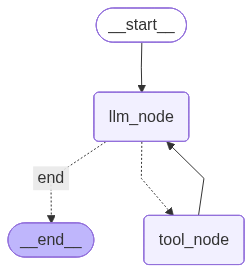

In [13]:

from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Add nodes to the graph
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

# Add edges between nodes
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call,{"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)


react_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(react_graph.get_graph().draw_mermaid_png())

In [14]:
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

Impersonate 'chrome_109' does not exist, using 'random'


BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=search_duckduckgo({"query": "latest news on AI"})</function>'}}